# Learning to optimize (L2O) with gradient-based correction layer in Neuromancer.

This tutorial demonstrates L2O methodology with   gradient-based correction layer introduced in the [DC3 paper](https://arxiv.org/abs/2104.12225).

## L2O Problem Setup

<img src="./L2O_methodology.PNG" width="600">

In L2O, we replace repeated online optimization with a learned solution operator. Given problem parameters

$$
\xi = (a,p),
$$

we train a neural network to predict the primal decision variables

$$
z = (x,y) = \mathcal{S}_{\theta}(\xi).
$$

The network output is then evaluated using the optimization objective and constraint penalties. To improve feasibility, we insert a differentiable gradient-based correction layer that reduces inequality constraint violations before computing the final loss. The complete pipeline is therefore

$$
\xi
\;\longrightarrow\;
\mathcal{S}_{\theta}(\xi)
\;\longrightarrow\;
\mathrm{Correction}
\;\longrightarrow\;
z^K(\xi).
$$

This provides an end-to-end differentiable program for learning approximate solutions to parametric nonlinear programs.

### References

[1]  [Priya L. Donti, David Rolnick, J. Zico Kolter, Deep Constraint Completion and Correction (DC3), ICLR, 2021](https://arxiv.org/abs/2104.12225)

[2]  [Neuromancer](https://github.com/pnnl/neuromancer)


## NeuroMANCER and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [92]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

### Import

In [93]:
import torch
import torch.nn as nn
import numpy as np
import neuromancer.slim as slim
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from casadi import *
import casadi
import time

In [94]:
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.dataset import DictDataset
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks, solvers
from neuromancer.system import Node

### Specific parametric nonlinear programming problem
We consider the following parametric nonlinear programming problem (pNLP):

$$
\begin{align}
&\text{minimize } &&  (1-x)^2 + a(y-x^2)^2\\
&\text{subject to} && \left(\frac{p}{2}\right)^2 \le x^2 + y^2 \le p^2\\
& && x \ge y
\end{align}
$$

with parameters $p, a$ and decision variables $x, y$.


## Dataset

In [95]:
data_seed = 408  # random seed used for simulated data
np.random.seed(data_seed)
torch.manual_seed(data_seed);

Randomly sample parameters from a uniform distribution: $0.5\le p\le2.0$;  $0.2\le a\le1.2$

In [96]:
nsim = 5000  # number of datapoints: increase sample density for more robust results
# create dictionaries with sampled datapoints with uniform distribution
a_low, a_high, p_low, p_high = 0.2, 1.2, 0.5, 2.0
samples_train = {"a": torch.FloatTensor(nsim, 1).uniform_(a_low, a_high),
                 "p": torch.FloatTensor(nsim, 1).uniform_(p_low, p_high)}
samples_dev = {"a": torch.FloatTensor(nsim, 1).uniform_(a_low, a_high),
               "p": torch.FloatTensor(nsim, 1).uniform_(p_low, p_high)}
samples_test = {"a": torch.FloatTensor(nsim, 1).uniform_(a_low, a_high),
               "p": torch.FloatTensor(nsim, 1).uniform_(p_low, p_high)}
# create named dictionary datasets
train_data = DictDataset(samples_train, name='train')
dev_data = DictDataset(samples_dev, name='dev')
test_data = DictDataset(samples_test, name='test')
# create torch dataloaders for the Trainer
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, num_workers=0,
                                           collate_fn=train_data.collate_fn, shuffle=True)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=32, num_workers=0,
                                         collate_fn=dev_data.collate_fn, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, num_workers=0,
                                         collate_fn=test_data.collate_fn, shuffle=True)
# note: training quality will depend on the DataLoader parameters such as batch size and shuffle

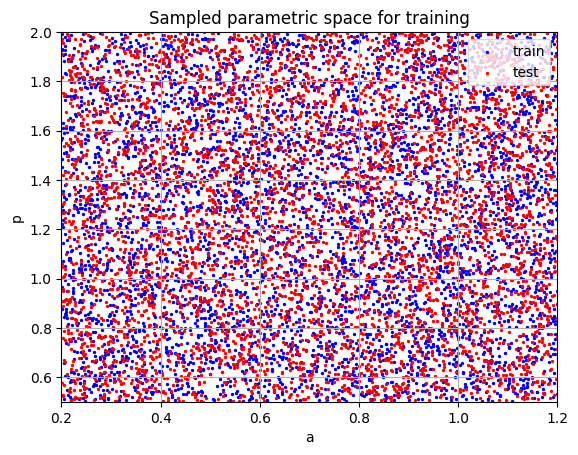

In [97]:
# visualize taining and test samples for 2D parametric space
a_train = samples_train['a'].numpy()
p_train = samples_train['p'].numpy()
a_dev = samples_dev['a'].numpy()
p_dev = samples_dev['p'].numpy()
plt.figure()
plt.scatter(a_train, p_train, s=2., c='blue', marker='o')
plt.scatter(a_dev, p_dev, s=2., c='red', marker='o')
plt.title('Sampled parametric space for training')
plt.xlim(a_low, a_high)
plt.ylim(p_low, p_high)
plt.grid(True)
plt.xlabel('a')
plt.ylabel('p')
plt.legend(['train', 'test'], loc='upper right')
plt.show()
plt.show(block=True)

### Primal Solution Map Architecture

We define the primal solution map $\mathcal{S}_{\theta}$ as a multi-layer perceptron (MLP) neural network, and create symbolic Node wrapper for a neural network architecture creating a mapping of problem parameters $a, p$ onto decision variables:
$(x,y) = \mathcal{S}_{\theta}(a, p)$



In [98]:
# define neural architecture for the trainable solution map
func = blocks.MLP(insize=2, outsize=2,
                bias=True,
                linear_map=slim.maps['linear'],
                nonlin=nn.ReLU,
                hsizes=[80] * 4)
# wrap neural net into symbolic representation of the solution map via the Node class: sol_map(xi) -> x
sol_map = Node(func, ['a', 'p'], ['x'], name='map')

## Objective and Constraints in Neuromancer

We now encode the objective and constraints symbolically using Neuromancer. For each sampled parameter pair
$
\xi=(a,p),
$
the neural solution map predicts primal solution variables
$z =(x,y) = \mathcal{S}_{\theta}(\xi)$

The objective is the Rosenbrock-type function

$$
J(z;\xi)
=
(1-x)^2
+
a(y-x^2)^2.
$$

The feasible set is defined by three inequality constraints,

$$
x \ge y,
\qquad
\left(\frac{p}{2}\right)^2 \le x^2+y^2,
\qquad
x^2+y^2 \le p^2.
$$

Equivalently, in standard inequality form,

$$
g_1(z;\xi)=y-x \le 0,
$$

$$
g_2(z;\xi)=\left(\frac{p}{2}\right)^2-x^2-y^2 \le 0,
$$

$$
g_3(z;\xi)=x^2+y^2-p^2 \le 0.
$$

Neuromancer represents these expressions as symbolic variables, objectives, and constraints. During training, the objective and constraint violation penalties are combined into a differentiable loss function, allowing gradients to be propagated through the neural solution map and the correction layer.


In [99]:
"""
variable is a basic symbolic abstraction in Neuromancer
   x = variable("variable_name")                      (instantiates new variable)  
variable construction supports:
   algebraic expressions:     x**2 + x**3 + 5     (instantiates new variable)  
   slicing:                   x[:, i]             (instantiates new variable)  
   pytorch callables:         torch.sin(x)        (instantiates new variable)  
   constraints definition:    x <= 1.0            (instantiates Constraint object) 
   objective definition:      x.minimize()        (instantiates Objective object) 
to visualize computational graph of the variable use x.show() method          
"""

# define primal decision variables
x = variable("x")[:, [0]]
y = variable("x")[:, [1]]
# problem parameters sampled in the dataset
p = variable('p')
a = variable('a')

# objective function
f = (1-x)**2 + a*(y-x**2)**2
obj = f.minimize(weight=1.0, name='obj')

# constraints
Q_con = 100.0   #  constraints penalty weights
con_1 = Q_con*(x >= y)
con_2 = Q_con*((p/2)**2 <= x**2+y**2)
con_3 = Q_con*(x**2+y**2 <= p**2)
con_1.name = 'c1'
con_2.name = 'c2'
con_3.name = 'c3'

### Differentiable Gradient-Based Correction Layer

The neural network provides an initial prediction

$$
z^0
=
\mathcal{S}_{\theta}(\xi),
\qquad
z=(x,y).
$$

This prediction may not satisfy the inequality constraints. Following the   [DC3 paper](https://arxiv.org/abs/2104.12225), we apply an unrolled differentiable feasibility correction layer that takes gradient steps on the constraint violation penalty. For constraints written in standard form

$$
g_r(z;\xi)\le 0,
$$

define the violation loss

$$
V(z;\xi)
=
\sum_r
\left\|
\mathrm{ReLU}\big(g_r(z;\xi)\big)
\right\|_2^2.
$$

The correction layer $\rho_K$ performs a fixed number of gradient-based updates, initialized with the neural network prediction
$z^0=\mathcal S_\theta(\xi)$, to produce the corrected solution $z^K$ via the following update rule:

$$
z^{j+1}
=
z^j
-
\alpha_j
\nabla_z V(z^j;\xi),
\qquad
j=0,\ldots,K-1.
$$

The corrected output is

$$
z^K
=
\rho_K\!\left(\mathcal{S}_{\theta}(\xi)\right)
$$

 Because every correction step is differentiable, the full map

$$
\xi
\longmapsto
\mathcal{S}_{\theta}(\xi)
\longmapsto
z^K(\xi)
$$

is a differentiable computational graph. Gradients are computed by backpropagation through the unrolled correction steps, analogous to BPTT for an unrolled dynamical system.

In this notebook, the correction layer using gradient updates with step size decay is implemented using Neuromancer's [`GradientProjection`](https://github.com/pnnl/neuromancer/blob/master/src/neuromancer/modules/solvers.py) class, applied to the inequality constraints selected below. See also the [DC3 paper](https://arxiv.org/abs/2104.12225) for the original constraint completion and correction framework.


In [100]:
# instantiate DC3 correction layer
num_steps = 4
step_size = 0.1
proj = solvers.GradientProjection(constraints=[con_2, con_3],          # inequality constraints to be corrected
                                  input_keys=["x"],                    # primal variables to be updated
                                  num_steps=num_steps,                 # number of rollout steps of the solver method
                                  step_size=step_size,                 # step size of the solver method
                                  decay=0.1,                           # decay factor of the step size
                                  name='proj')

### Construct Differentiable Optimization Problem

We now assemble the neural solution map, the correction layer, the objective, and the constraints into a single differentiable program using Neuromancer's [`Problem`](https://github.com/pnnl/neuromancer/blob/master/src/neuromancer/problem.py) abstraction.

For a training set of sampled problem parameters

$$
\{\xi_i\}_{i=1}^{m},
\qquad
\xi_i=(a_i,p_i),
$$

we learn a parameterized solution operator

$$
\mathcal{S}_{\theta}:\xi_i\mapsto z_{\theta,i}=(x_{\theta,i},y_{\theta,i}).
$$

The raw neural prediction is passed through the differentiable DC3 correction layer,

$$
z_{\theta,i}^{K}
=
\rho_K\!\left(\mathcal{S}_{\theta}(\xi_i)\right),
$$

and the network parameters are trained by solving the unsupervised L2O problem

$$
\begin{aligned}
\min_{\theta}\quad
&
\frac{1}{m}
\sum_{i=1}^{m}
\Big[
J(z_{\theta,i}^{K};\xi_i)
+
\lambda
\sum_r
\left\|
\mathrm{ReLU}
\big(
g_r(z_{\theta,i}^{K};\xi_i)
\big)
\right\|_2^2
\Big]
\\
\text{s.t.}\quad
&
z_{\theta,i}^{+}
=
\rho_K\!\left(\mathcal{S}_{\theta}(\xi_i)\right),
\qquad
\xi_i\sim\mathcal{D}.
\end{aligned}
$$

Here, $J$ is the objective function, $g_r$ are the inequality constraints, $\lambda$ denotes constraint penalty weights, and $\rho_K$ is the $K$-step differentiable gradient-based correction operator.

This formulation is different from supervised regression to known optimal solutions. Instead, the neural network is trained directly through the optimization objective and constraint violations, allowing it to learn a parametric optimizer from sampled problem instances.


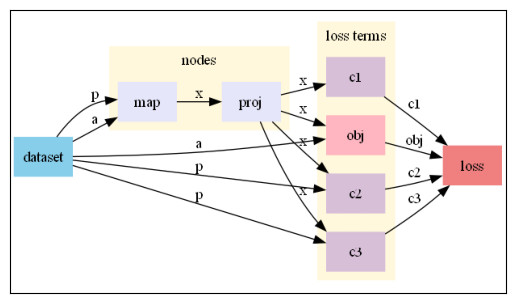

In [101]:
# constrained optimization problem construction
objectives = [obj]
constraints = [con_1, con_2, con_3]
components = [sol_map, proj]
    
# create penalty method loss function
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss,
                  grad_inference=True   # argument for allowing computation of gradients at the inference time
                  )
problem.show()

### Learning the Parametric Solution Map in NeuroMANCER

In [102]:
lr = 0.002      # step size for gradient descent
epochs = 100    # number of training epochs
warmup = epochs    # number of epochs to wait before enacting early stopping policy
patience = epochs  # number of epochs with no improvement in eval metric to allow before early stopping

In [103]:
optimizer = torch.optim.AdamW(problem.parameters(), lr=lr)

# define trainer
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_loader,
    optimizer,
    epochs=epochs,
    patience=patience,
    warmup=warmup)

In [ ]:
# Train NLP solution map
best_model = trainer.train()
best_outputs = trainer.test(best_model)
# load best model dict
problem.load_state_dict(best_model)

epoch: 0  train_loss: 1.557287573814392


### Evaluate Learned Solution Map

Generate inference time scenario $\xi_i = (a_i,p_i)$ within training distribution.

In [87]:
# selected parametric instance for inference time evaluation
p = 1.0
a = 1.0

obtain primal solution from the learned solution map $
z_{\theta,i}^{K}
=
\rho_K\!\left(\mathcal{S}_{\theta}(\xi_i)\right),
$

In [88]:
# Solution to mpNLP via Neuromancer
datapoint = {'a': torch.tensor([[a]]), 'p': torch.tensor([[p]]),
             'name': 'test'}
model_out = problem(datapoint)
x_nm = model_out['test_' + "x"][0, 0].detach().numpy()
y_nm = model_out['test_' + "x"][0, 1].detach().numpy()
print(x_nm)
print(y_nm)

1.0052625
0.7333


#### Get pNLP solution from CasADi for comparison

[CasADi](https://web.casadi.org/) is an open-source tool for constrained optimization and optimal control that has influenced the development of NeuroMANCER.

In [89]:
# instantiate casadi optimizaiton problem class
def NLP_param(a, p, opti_silent=False):
    opti = casadi.Opti()
    # define variables
    x = opti.variable()
    y = opti.variable()
    p_opti = opti.parameter()
    a_opti = opti.parameter()
    # define objective and constraints
    opti.minimize((1 - x) ** 2 + a_opti * (y - x ** 2) ** 2)
    opti.subject_to(x >= y)
    opti.subject_to((p_opti / 2) ** 2 <= x ** 2 + y ** 2)
    opti.subject_to(x ** 2 + y ** 2 <= p_opti ** 2)
    # select IPOPT solver and solve the NLP
    if opti_silent:
        opts = {'ipopt.print_level': 0, 'print_time': 0, 'ipopt.sb': 'yes'}
    else:
        opts = {}
    opti.solver('ipopt', opts)
    # set parametric values
    opti.set_value(p_opti, p)
    opti.set_value(a_opti, a)
    return opti, x, y

# construct casadi problem
opti, x, y = NLP_param(a, p)
# solve NLP via casadi
sol = opti.solve()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        6
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        2

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 2.50e-01 1.67e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [90]:
print(f"x = {sol.value(x)}")
print(f"y = {sol.value(y)}")

x = 0.8081695826847699
y = 0.588949838491767


#### Compare: NeuroMANCER vs. CasADi

When training the neural network, we choose deliberately bad tuning of the constraints penalties to illustrate the correction mechanism of the projected gradient method.

1.0052625
0.7333


C:\Users\drgon\AppData\Local\Temp\ipykernel_24824\2820142510.py:22: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  if hasattr(cg1, 'collections') and cg1.collections:
C:\Users\drgon\AppData\Local\Temp\ipykernel_24824\2820142510.py:23: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cg1.collections,
C:\Users\drgon\AppData\Local\Temp\ipykernel_24824\2820142510.py:27: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  if hasattr(cg2, 'collections') and cg2.collections:
C:\Users\drgon\AppData\Local\Temp\ipykernel_24824\2820142510.py:28: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cg2.collections,
C:\Users\drgon\AppData\Local\Temp\ipykernel_24824\2820142510.py:32: MatplotlibDeprecationWar

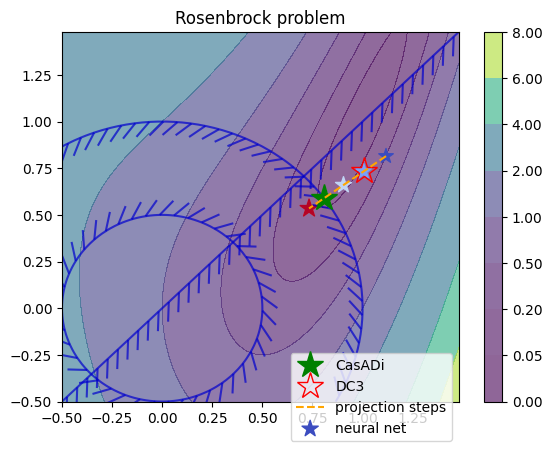

In [91]:
"""
Plots
"""
x1 = np.arange(-0.5, 1.5, 0.02)
y1 = np.arange(-0.5, 1.5, 0.02)
xx, yy = np.meshgrid(x1, y1)

# eval objective and constraints
J = (1 - xx) ** 2 + a * (yy - xx ** 2) ** 2
c1 = xx - yy
c2 = xx ** 2 + yy ** 2 - (p / 2) ** 2
c3 = -(xx ** 2 + yy ** 2) + p ** 2

fig, ax = plt.subplots(1, 1)
cp = ax.contourf(xx, yy, J,
                 levels=[0, 0.05, 0.2, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0],
                 alpha=0.6)
fig.colorbar(cp)
ax.set_title('Rosenbrock problem')

cg1 = ax.contour(xx, yy, c1, [0], colors='mediumblue', alpha=0.7)
if hasattr(cg1, 'collections') and cg1.collections:
    plt.setp(cg1.collections,
            path_effects=[patheffects.withTickedStroke()], alpha=0.7)

cg2 = ax.contour(xx, yy, c2, [0], colors='mediumblue', alpha=0.7)
if hasattr(cg2, 'collections') and cg2.collections:
    plt.setp(cg2.collections,
            path_effects=[patheffects.withTickedStroke()], alpha=0.7)

cg3 = ax.contour(xx, yy, c3, [0], colors='mediumblue', alpha=0.7)
if hasattr(cg3, 'collections') and cg3.collections:
    plt.setp(cg3.collections,
            path_effects=[patheffects.withTickedStroke()], alpha=0.7)

# Solution to pNLP via Neuromancer
datapoint = {'a': torch.tensor([[a]]), 'p': torch.tensor([[p]]),
             'name': 'test'}
model_out = problem(datapoint)
x_nm = model_out['test_' + "x"][0, 0].detach().numpy()
y_nm = model_out['test_' + "x"][0, 1].detach().numpy()
print(x_nm)
print(y_nm)

# intermediate projection steps
x_proj = sol_map(datapoint)
proj.num_steps = 1    # set projections steps to 1 for visualisation
X_projected = [x_proj['x'].detach().numpy()]
for steps in range(num_steps):
    proj_inputs = {**datapoint, **x_proj}
    x_proj = proj(proj_inputs)
    X_projected.append(x_proj['x'].detach().numpy())
projected_steps = np.concatenate(X_projected, axis=0)

# plot optimal solutions CasADi vs Neuromancer
ax.plot(sol.value(x), sol.value(y), 'g*', markersize=20, label='CasADi')
ax.plot(x_nm, y_nm, 'r*', fillstyle='none', markersize=20, label='DC3')
# plot projected steps
marker_sizes = list(np.linspace(120, 180, num_steps+1))
color_gradient = list(np.linspace(0, 1, num_steps+1))
ax.plot(projected_steps[:, 0], projected_steps[:, 1], '--', c='orange',
        label='projection steps')
ax.scatter(projected_steps[:, 0], projected_steps[:, 1],
           s=marker_sizes, marker='*', c=color_gradient, cmap='coolwarm',
           label='neural net')
plt.legend(bbox_to_anchor=(1.0, 0.15))
plt.show(block=True)



### Next Steps

In this notebook, we learned a differentiable parametric solution operator for constrained optimization using NeuroMANCER and the DC3 feasibility restoration layer.

Several interesting extensions are left as exercises:

- **Out-of-distribution generalization.** Evaluate the learned solution operator on unseen problem parameters outside the training distribution and compare its optimality and feasibility against in-distribution performance.

- **Correction depth.** Investigate the tradeoff between the number of correction steps $K$, solution quality, feasibility, and inference time.
